# **Classification of Claims in TikTok Videos**
**Fourth Stage - Regression Analysis**

**Situation:** we're getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

We're interested in how different variables are associated with whether a user is verified. Earlier,we observed that if a user is verified, they are much more likely to post opinions. Now, we decided to explore how to predict verified status to help us understand how video characteristics relate to verified users. Therefore, we're going to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

# **Regression modeling**


In this stage, we will build a logistic regression model in Python. As logistic regression helps us estimate the probability of an outcome. It allows us to consider more than one variable against the variable we're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this notebook is to perform of EDA and regression modeling.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This stage has three parts:*

**Part 1:** EDA & Checking Model Assumptions

**Part 2:** Model Building and Evaluation

**Part 3:** Interpreting Model Results


# **Building a regression model**

# **PACE stages**

Throughout this notebooks, we'll us the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

### **Part 1. Imports and loading**
We'll import the data and packages that we've learned are needed for building regression models.

In [ ]:
# Importing packages for data manipulation
import pandas as pd
import numpy as np
# Importing packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Importing packages for data preprocessing
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
# Importing packages for data modeling
from sklearn.linear_model import LogisticRegression


In [ ]:
# Loading dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv", index_col=0)

## **PACE: Analyze**

Some purposes of EDA before constructing a logistic regression model:

+ Cleaning the data from ouliers and missing values.
+ Discovering and visualizing the relations between variables for selecting the appripriate modeling.
+ Structuring new features from available data.

### **Part 2a. Exploring data with EDA**

We'll analyze the data and check for and handle missing values and duplicates.

In [ ]:
# Displaying first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


In [ ]:
# Getting number of rows and columns
data.shape

(19382, 12)

In [ ]:
# Getting data types of columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

In [ ]:
# Getting basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


In [ ]:
# Generating basic descriptive statistics
data.describe(include='all')

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,19084,1.938200e+04,19382.000000,19084,19382,19382,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
unique,NaN,2,NaN,NaN,19012,2,3,NaN,NaN,NaN,NaN,NaN
top,NaN,claim,NaN,NaN,a friend read in the media a claim that badmi...,not verified,active,NaN,NaN,NaN,NaN,NaN
freq,NaN,9608,NaN,NaN,2,18142,15663,NaN,NaN,NaN,NaN,NaN
mean,9691.500000,NaN,5.627454e+09,32.421732,NaN,NaN,NaN,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,NaN,2.536440e+09,16.229967,NaN,NaN,NaN,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,NaN,1.234959e+09,5.000000,NaN,NaN,NaN,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,NaN,3.430417e+09,18.000000,NaN,NaN,NaN,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,NaN,5.618664e+09,32.000000,NaN,NaN,NaN,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,NaN,7.843960e+09,47.000000,NaN,NaN,NaN,504327.000000,125020.000000,18222.000000,1156.250000,292.000000


In [ ]:
# Checking for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [ ]:
# Dropping rows with missing values
data = data.dropna(axis=0)

In [ ]:
# Displaying first few rows after handling missing values
data.reset_index(drop=True)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19079,19080,opinion,1492320297,49,in our opinion the earth holds about 11 quinti...,not verified,active,6067.0,423.0,81.0,8.0,2.0
19080,19081,opinion,9841347807,23,in our opinion the queens in ant colonies live...,not verified,active,2973.0,820.0,70.0,3.0,0.0
19081,19082,opinion,8024379946,50,in our opinion the moon is moving away from th...,not verified,active,734.0,102.0,7.0,2.0,1.0
19082,19083,opinion,7425795014,8,in our opinion lightning strikes somewhere on ...,not verified,active,3394.0,655.0,123.0,11.0,4.0


Checking for and handling duplicates.

In [ ]:
# Checking for duplicates
data = data.drop_duplicates()

Checking for and handling outliers.

<Axes: xlabel='video_duration_sec'>

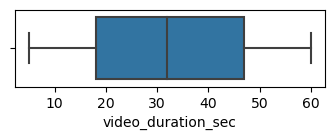

In [ ]:
# Creating a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(4,1))
sns.boxplot(x=data['video_duration_sec'])


<Axes: xlabel='video_view_count'>

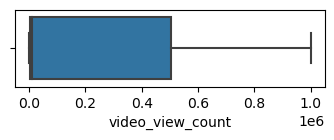

In [ ]:
# Creating a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(4,1))
sns.boxplot(x=data['video_view_count'])

<Axes: xlabel='video_like_count'>

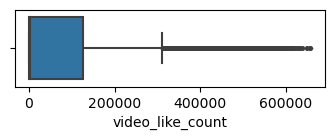

In [ ]:
# Creating a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(4,1))
sns.boxplot(x=data['video_like_count'],fliersize=2)

<Axes: xlabel='video_comment_count'>

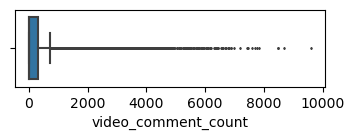

In [ ]:
# Creating a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(4,1))
sns.boxplot(x=data['video_comment_count'], fliersize=1)

In [ ]:
# Checking for and handling outliers for video_like_count
IQR = data['video_like_count'].quantile(0.75) - data['video_like_count'].quantile(0.25)
threshold = data['video_like_count'].quantile(0.75) + 1.5 * IQR
data['video_like_count'] = np.where(data['video_like_count']>threshold, threshold, data['video_like_count'])

Let's check class balance of the target variable. The goal is to predict whether the user of a given post is verified or unverified.

In [ ]:
# Check class balance
data['verified_status'].value_counts(normalize=True)

311333.875

Approximately 94.2% of the dataset represents videos posted by unverified accounts and 5.8% represents videos posted by verified accounts. So the outcome variable is not very balanced.

We'll use resampling to create class balance in the outcome variable.

In [ ]:
# Using resampling to create class balance in the outcome variable
from sklearn.utils import resample
# Identifying data points from majority and minority classes
majority = data[data['verified_status']=='not verified']
minority = data[data['verified_status']=='verified']
# Upsampling the minority class (which is "verified")
sample = resample(minority, replace=True, n_samples=len(majority), random_state=43)
# Combining majority class with upsampled minority class
data = pd.concat([sample,majority], axis=0).reset_index(drop=True)
# Displaying new class counts
data['verified_status'].value_counts()

verified_status
verified        17884
not verified    17884
Name: count, dtype: int64

Let's get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



We'll also extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [ ]:
# Getting the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
data['Length'] = [len(x) for x in data['video_transcription_text']]
data.groupby('verified_status')['Length'].mean()

verified_status
not verified    89.401141
verified        84.282208
Name: Length, dtype: float64

we'll visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

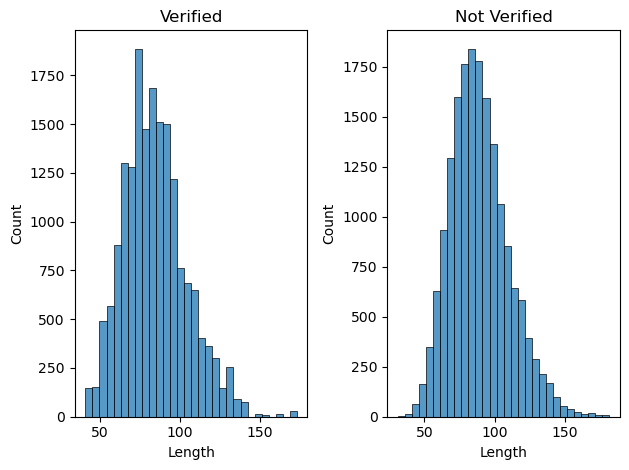

In [ ]:
# Visualizing the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Creating two histograms in one plot
fig, axes = plt.subplots(1,2)
sns.histplot(data=data[data['verified_status']=='verified'], x='Length', ax=axes[0],bins=30)
sns.histplot(data=data[data['verified_status']=='not verified'], x='Length',ax= axes[1],bins=30)
axes[0].set_title('Verified')
axes[1].set_title('Not Verified')

plt.tight_layout()

### **Part 2b. Examine correlations**

Next, we'll code a correlation matrix to help determine most correlated variables.

In [ ]:
# Coding a correlation matrix to help determine most correlated variables
corr = data.drop(columns=['#','video_id']).corr(numeric_only=True,method='pearson')

Visualizing a correlation heatmap of the data.

<Axes: >

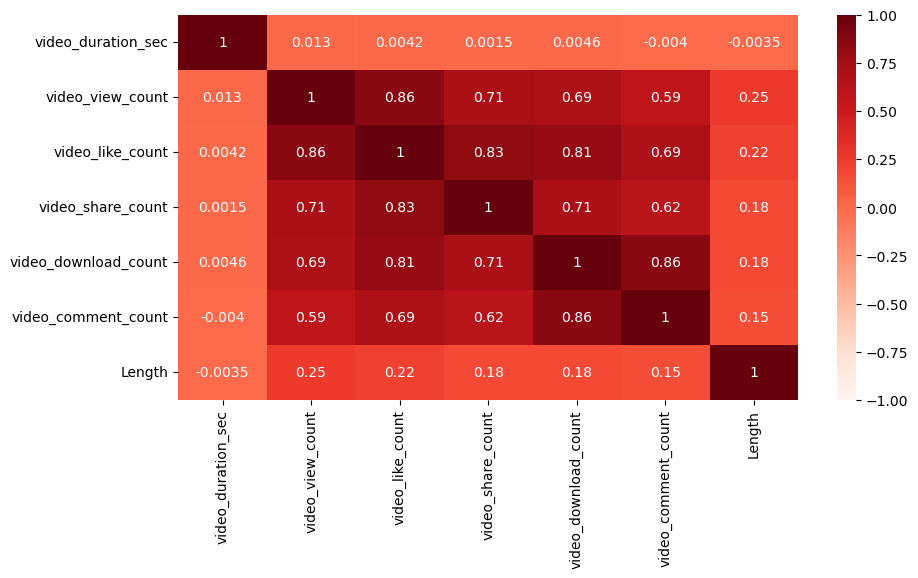

In [ ]:
# Creating a heatmap to visualize how correlated variables are
plt.figure(figsize=(10,5))
sns.heatmap(corr, cmap='Reds', vmin=-1, vmax=1,annot=True)

One of the model assumptions for logistic regression is no severe multicollinearity among the features. Taking this into consideration as we examine the heatmap, interactions count variables seems to be correlated. especially `video_like_count` seems to be highly correlated with other variables so we should exclude it.

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model.

### **Part 3a. Selecting variables**

In [ ]:
# Selecting outcome variable
y = data['verified_status']

In [ ]:
# Selecting features
data.head()
x = data.drop(columns = ['#','video_id','video_transcription_text','verified_status','video_like_count'])
# Displaying first few rows of features dataframe
x.head()

,claim_status,video_duration_sec,author_ban_status,video_view_count,video_share_count,video_download_count,video_comment_count,Length
0,opinion,19,active,5503.0,214.0,5.0,1.0,76
1,opinion,23,active,1726.0,141.0,3.0,1.0,82
2,claim,18,banned,692254.0,100714.0,1099.0,236.0,112
3,claim,48,active,308048.0,4165.0,724.0,476.0,111
4,opinion,15,active,994.0,60.0,5.0,1.0,110


### **Part 3b. Train-test split**

In [ ]:
# Splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

We need to confirm that the dimensions of the training and testing sets are in alignment.

In [ ]:
# Getting shape of each training and testing set
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(28614, 8) (7154, 8) (28614,) (7154,)


### **Part 3c. Encoding variables**

In [ ]:
# Checking data types of the features
x.dtypes

claim_status             object
video_duration_sec        int64
author_ban_status        object
video_view_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
Length                    int64
dtype: object

In [ ]:
# Getting unique values in `claim_status`
x['claim_status'].unique()

array(['opinion', 'claim'], dtype=object)

In [ ]:
# Getting unique values in `author_ban_status`
x['author_ban_status'].unique()

array(['active', 'banned', 'under review'], dtype=object)

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Let's encode categorical features in the training set using an appropriate method.

In [ ]:
# Selecting the training features that needs to be encoded
goal = x_train[['claim_status','author_ban_status']]

# Displaying first few rows
goal.head()

,claim_status,author_ban_status
4351,claim,active
18967,claim,active
24897,claim,active
5916,opinion,active
10822,opinion,banned


In [ ]:
# Setting up an encoder for one-hot encoding the categorical features
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first',sparse_output=False,handle_unknown='ignore')
encoder.set_output(transform='pandas');

In [ ]:
# Fitting and transforming the training features using the encoder
encoded = encoder.fit(goal).transform(goal)
encoded.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
4351,0.0,0.0,0.0
18967,0.0,0.0,0.0
24897,0.0,0.0,0.0
5916,1.0,0.0,0.0
10822,1.0,1.0,0.0


In [ ]:
# Getting feature names from encoder
encoder.get_feature_names_out()


array(['claim_status_opinion', 'author_ban_status_banned',
       'author_ban_status_under review'], dtype=object)

In [ ]:
# Displaying first few rows of encoded training features
encoded.shape

(28614, 3)

In [ ]:
# Displaying first few rows of `X_train` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
x_train.drop(columns=['claim_status', 'author_ban_status'], inplace=True)

In [ ]:
# Concatenating `X_train` and `X_train_encoded_df` to form the final dataframe for training data (`X_train_final`)
encoded.reset_index(drop=True, inplace=True)
x_train.reset_index(drop=True, inplace=True)
X_train = pd.concat([x_train,encoded], axis=1)

In [ ]:
# Checking data type of outcome variable
X_train.reset_index(drop=True, inplace=True)
y.dtype

dtype('O')

In [ ]:
# Getting unique values of outcome variable
y.unique()

(28614, 9)

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

In [ ]:
# Setting up an encoder for one-hot encoding the categorical outcome variable
Y_train = encoder.fit(pd.DataFrame(y_train)).transform(pd.DataFrame(y_train))

In [ ]:
# Encoding the training outcome variable
Y_train = Y_train['verified_status_verified'].reset_index(drop=True)

### **Part 3d. Model building**

Constructing a model and fitting it to the training set.

In [ ]:
# Constructing a logistic regression model and fitting it to the training set
clf = LogisticRegression()
model = clf.fit(X_train, Y_train)

## **PACE: Execute**

### **Taks 4a. Results and evaluation**

Evaluating our model.

In [ ]:
# Selecting the testing features that needs to be encoded
goal_test = x_test[['claim_status','author_ban_status']]
x_test.drop(columns=['claim_status', 'author_ban_status'], inplace=True)
encoded_test = encoder.fit(goal_test).transform(goal_test)
encoded_test.reset_index(drop=True, inplace=True)
x_test.reset_index(drop=True, inplace=True)
y_test.reset_index(drop=True, inplace=True)
X_test = pd.concat([x_test, encoded_test], axis=1)

Let's test the logistic regression model. Using the model to make predictions on the encoded testing set.

In [ ]:
# Using the logistic regression model to get predictions on the encoded testing set
y_pred = model.predict(X_test)

In [ ]:
# The predictions on the encoded testing set
y_pred_df = pd.DataFrame({'verified_status_verified':y_pred})

In [ ]:
# Displaying the true labels of the testing set
y_pred_df[y_pred_df['verified_status_verified']==1]

,verified_status_verified
1,1.0
3,1.0
4,1.0
5,1.0
6,1.0
...,...
7146,1.0
7149,1.0
7150,1.0
7151,1.0


Encoding the true labels of the testing set so it can be compared to the predictions.

In [ ]:
y_test = y_test.reset_index().drop(columns='index')
encoded_y_test = encoder.fit(y_test).transform(y_test)
encoded_y_test

,verified_status_verified
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
7149,0.0
7150,1.0
7151,0.0
7152,0.0


### **Part 4b. Visualizing model results**

We'll create a confusion matrix to visualize the results of the logistic regression model.

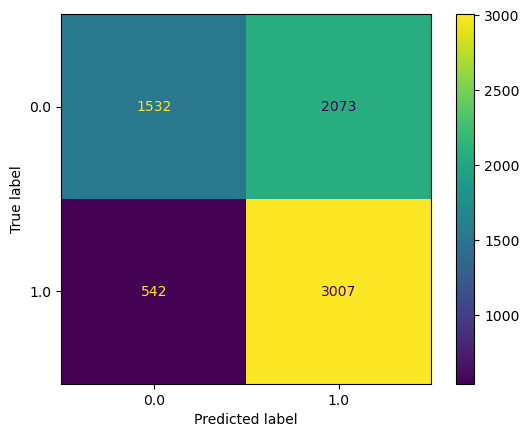

In [ ]:
# Computing values for confusion matrix
cm = metrics.confusion_matrix(encoded_y_test,y_pred_df,labels= model.classes_)
# Creating display of confusion matrix
cmplot = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = model.classes_)
# Plotting confusion matrix
cmplot.plot()

Next, we'll create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [ ]:
# Creating a classification report
print('Precision: ', metrics.precision_score(encoded_y_test,y_pred_df).round(2))
print('F1-Score: ', metrics.f1_score(encoded_y_test,y_pred_df).round(2))
print('Recall: ', metrics.recall_score(encoded_y_test,y_pred_df).round(2))
print('Accuracy: ', metrics.accuracy_score(encoded_y_test,y_pred_df).round(2))

Precision:  0.59
F1-Score:  0.7
Recall:  0.85
Accuracy:  0.63


### **Part 4c. Interpreting model coefficients**

In [ ]:
# Getting the feature names from the model and the model coefficients (which represent log-odds ratios)
results = pd.DataFrame(columns= X_test.columns, data= model.coef_, index=['Beta'])
results.T

,Beta
video_duration_sec,0.001343
video_view_count,-0.000002
video_share_count,0.000004
video_download_count,-0.000175
video_comment_count,0.000340
Length,0.003594
claim_status_opinion,0.000062
author_ban_status_banned,-0.000002
author_ban_status_under review,-0.000001


### **Part 4d. Conclusion**

1. Key Takeaways are:
   + A logistic regression model was choosed as the apropriate model for the goals of the project.
   + EDA and future engineering was done to help as consider the most important features for predicting the verification status.
   + scikit-learn library was very useful in spliting the data and developing the model and assesing its accuracy.
  
2. Most important results:
   + Outliers and missed values were removed from the data to improve the model accuracy.
   + Verification status appeared to be correlated with the independent variables with the above beta parameters.
   + The results of the model are as follow: Precision: 0.59, F1-Score: 0.7, Recall: 0.85, Accuracy: 0.63